# RaksaDana - BMRI.JK LSTM Modelling & Evaluation

## Setup

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp
from statsmodels.stats.diagnostic import acorr_ljungbox

import mlflow
import mlflow.tensorflow

warnings.filterwarnings('ignore')

TICKER      = 'BMRI.JK'
SAFE_TICKER = TICKER.replace('.', '_')
SEEDS       = [42, 123, 7]

ROOT          = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(ROOT, 'data', 'processed')
MODEL_DIR     = os.path.join(ROOT, 'models')
MLFLOW_DB     = os.path.join(ROOT, 'mlflow.db')
os.makedirs(MODEL_DIR, exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB}')
mlflow.set_experiment(f'RaksaDana-LSTM-{TICKER}')

print(f'TensorFlow {tf.__version__}   |   Ticker: {TICKER}')

2026/05/17 13:16:12 INFO mlflow.tracking.fluent: Experiment with name 'RaksaDana-LSTM-BMRI.JK' does not exist. Creating a new experiment.


TensorFlow 2.21.0   |   Ticker: BMRI.JK


## Data

In [2]:
with open(os.path.join(PROCESSED_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

sequences     = data['sequences']
scalers       = data['scalers']
feature_cols  = data['feature_cols']
target_idx    = data['target_idx']
window_size   = data['window_size']
featured_data = data['featured_data']

n_features = len(feature_cols)
scaler     = scalers[TICKER]
s          = sequences[TICKER]
X_train, y_train = s['X_train'], s['y_train']
X_test,  y_test  = s['X_test'],  s['y_test']

val_split   = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

print(f'Scaler    : {data.get("scaler_type", "?")} (fit: {data.get("scaler_fit", "?")})')
print(f'Features  : {n_features} -> {feature_cols}')
print(f'X_train   : {X_train.shape}   X_test : {X_test.shape}')
print(f'Train/Val : {X_tr.shape[0]} / {X_val.shape[0]}')

Scaler    : MinMaxScaler (fit: train_only)
Features  : 20 -> ['Open', 'High', 'Low', 'Close', 'Volume', 'ROE', 'EPS', 'DY', 'MA7', 'MA20', 'MA50', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'Daily_Return', 'Log_Return', 'Volume_MA7', 'MACD', 'MACD_signal']
X_train   : (2090, 60, 20)   X_test : (523, 60, 20)
Train/Val : 1776 / 314


## Model

In [3]:
CONFIG = {
    'units'      : 96,
    'dropout'    : 0.20,
    'rec_dropout': 0.10,
    'l2_reg'     : 5e-5,
    'lr'         : 3e-4,
    'batch_size' : 16,
    'epochs'     : 150,
    'es_patience': 25,
}

def build_model(input_shape, units, dropout, rec_dropout, l2_reg, lr, **_):
    model = Sequential([
        Bidirectional(
            LSTM(units, return_sequences=False,
                 recurrent_dropout=rec_dropout,
                 kernel_regularizer=l2(l2_reg)),
            input_shape=input_shape,
        ),
        LayerNormalization(),
        Dropout(dropout),
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(1),
    ])
    model.compile(optimizer=Adam(lr), loss='huber', metrics=['mae'])
    return model

build_model((window_size, n_features), **CONFIG).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 192)            │        89,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 192)            │           384 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         3,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,345 (364.63 KB)

 Trainable params: 93,345 (364.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [4]:
def get_callbacks(patience):
    return [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, start_from_epoch=15, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=8, min_lr=1e-6, verbose=0),
    ]

ensemble  = []
histories = []

for seed in SEEDS:
    tf.random.set_seed(seed)
    np.random.seed(seed)

    model   = build_model((window_size, n_features), **CONFIG)
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'],
        callbacks=get_callbacks(CONFIG['es_patience']),
        shuffle=False,
        verbose=0,
    )
    ensemble.append(model)
    histories.append(history.history)

    best_val = min(history.history['val_loss'])
    n_ep     = len(history.history['loss'])
    print(f'seed={seed:>4d}  epochs={n_ep:>3d}  best_val_loss={best_val:.5f}')

ensemble[0].save(os.path.join(MODEL_DIR, f'lstm_{SAFE_TICKER}_best.keras'))

seed=  42  epochs= 57  best_val_loss=0.01291
seed= 123  epochs=114  best_val_loss=0.01104
seed=   7  epochs= 46  best_val_loss=0.01659


## Training Curves

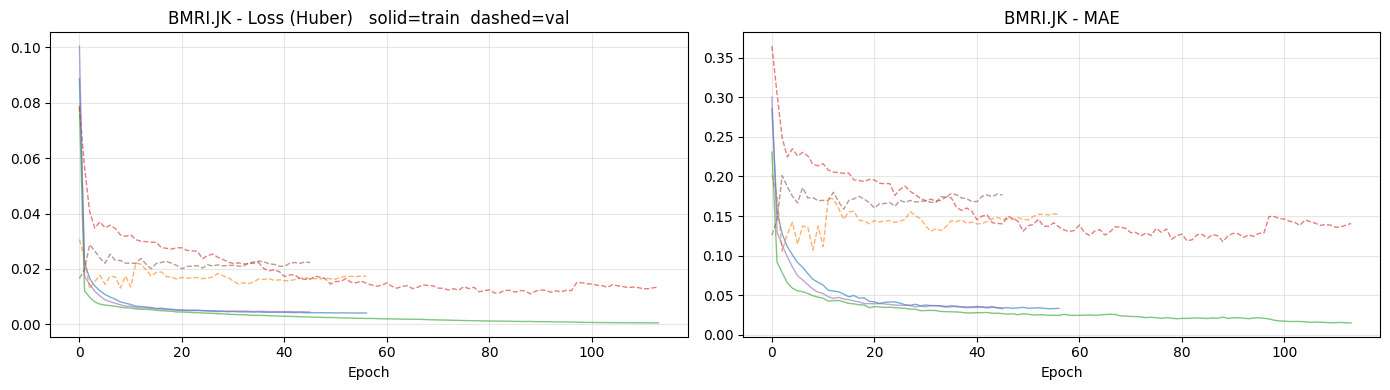

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for h in histories:
    axes[0].plot(h['loss'],     alpha=0.6, lw=1)
    axes[0].plot(h['val_loss'], alpha=0.6, lw=1, linestyle='--')
    axes[1].plot(h['mae'],      alpha=0.6, lw=1)
    axes[1].plot(h['val_mae'],  alpha=0.6, lw=1, linestyle='--')

axes[0].set_title(f'{TICKER} - Loss (Huber)   solid=train  dashed=val')
axes[1].set_title(f'{TICKER} - MAE')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, f'{SAFE_TICKER}_training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## Ensemble Prediction

In [6]:
def inverse_close(scaled_values):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

train_pred = np.mean([m.predict(X_train, verbose=0).flatten() for m in ensemble], axis=0)
test_pred  = np.mean([m.predict(X_test,  verbose=0).flatten() for m in ensemble], axis=0)

y_train_true = inverse_close(y_train)
y_train_pred = inverse_close(train_pred)
y_test_true  = inverse_close(y_test)
y_test_pred  = inverse_close(test_pred)

## Evaluation

In [7]:
def compute_metrics(y_true, y_pred):
    return {
        'MAE' : mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100,
        'R2'  : r2_score(y_true, y_pred),
    }

rows = [
    {'Split': 'Train', **compute_metrics(y_train_true, y_train_pred)},
    {'Split': 'Test',  **compute_metrics(y_test_true,  y_test_pred)},
]
metrics_df = pd.DataFrame(rows).set_index('Split')

(metrics_df.style
    .background_gradient(subset=['MAE', 'RMSE', 'MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'}))

,MAE,RMSE,MAPE,R2
Split,,,,
Train,166.89,255.09,6.3399%,0.8960
Test,"1,182.05","1,277.97",23.6904%,-3.3408


## Prediction vs Actual

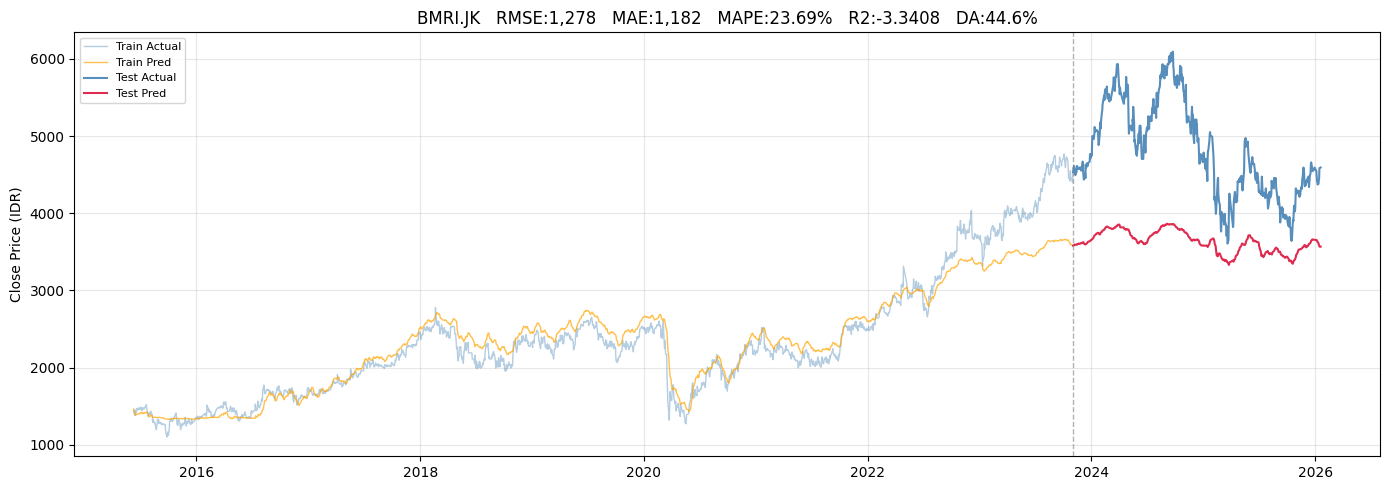

In [8]:
dates       = featured_data[TICKER].index
n_tr        = len(y_train_true)
train_dates = dates[window_size : window_size + n_tr]
test_dates  = dates[window_size + n_tr : window_size + n_tr + len(y_test_true)]

m  = compute_metrics(y_test_true, y_test_pred)
da = (np.sign(np.diff(y_test_true)) == np.sign(np.diff(y_test_pred))).mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_dates, y_train_true, color='steelblue', alpha=0.4, lw=1,   label='Train Actual')
ax.plot(train_dates, y_train_pred, color='orange',    alpha=0.7, lw=1,   label='Train Pred')
ax.plot(test_dates,  y_test_true,  color='steelblue', alpha=0.9, lw=1.5, label='Test Actual')
ax.plot(test_dates,  y_test_pred,  color='crimson',   alpha=0.9, lw=1.5, label='Test Pred')
ax.axvline(train_dates[-1], color='gray', linestyle='--', lw=1, alpha=0.6)

rmse = m['RMSE']
mae  = m['MAE']
mape = m['MAPE']
r2   = m['R2']
ax.set_title(f'{TICKER}   RMSE:{rmse:,.0f}   MAE:{mae:,.0f}   MAPE:{mape:.2f}%   R2:{r2:.4f}   DA:{da:.1f}%')
ax.set_ylabel('Close Price (IDR)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, f'{SAFE_TICKER}_prediction_vs_actual.png'), dpi=120, bbox_inches='tight')
plt.show()

## Test Set

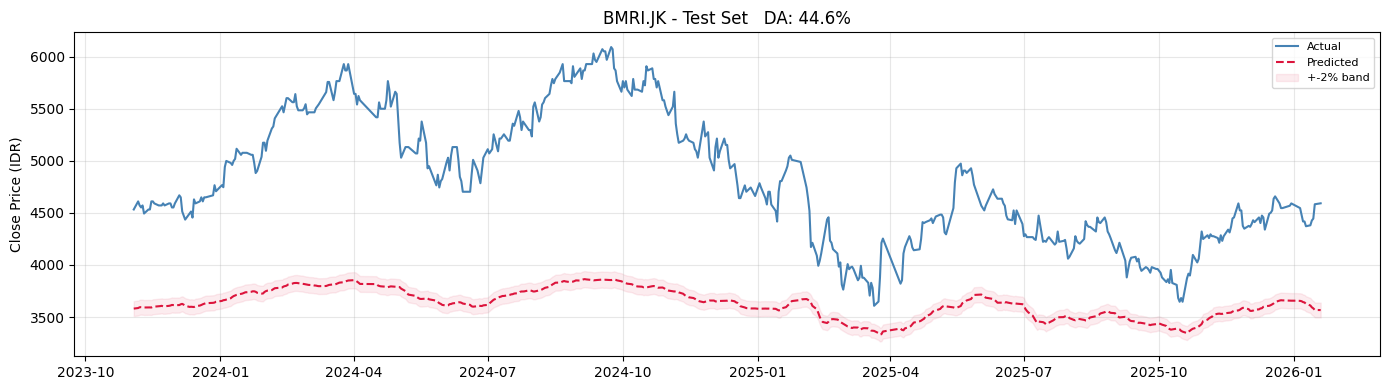

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_dates, y_test_true, color='steelblue', lw=1.5, label='Actual')
ax.plot(test_dates, y_test_pred, color='crimson',   lw=1.5, linestyle='--', label='Predicted')
ax.fill_between(test_dates, y_test_pred * 0.98, y_test_pred * 1.02,
                color='crimson', alpha=0.08, label='+-2% band')
ax.set_title(f'{TICKER} - Test Set   DA: {da:.1f}%')
ax.set_ylabel('Close Price (IDR)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, f'{SAFE_TICKER}_test_zoom.png'), dpi=120, bbox_inches='tight')
plt.show()

## Residuals

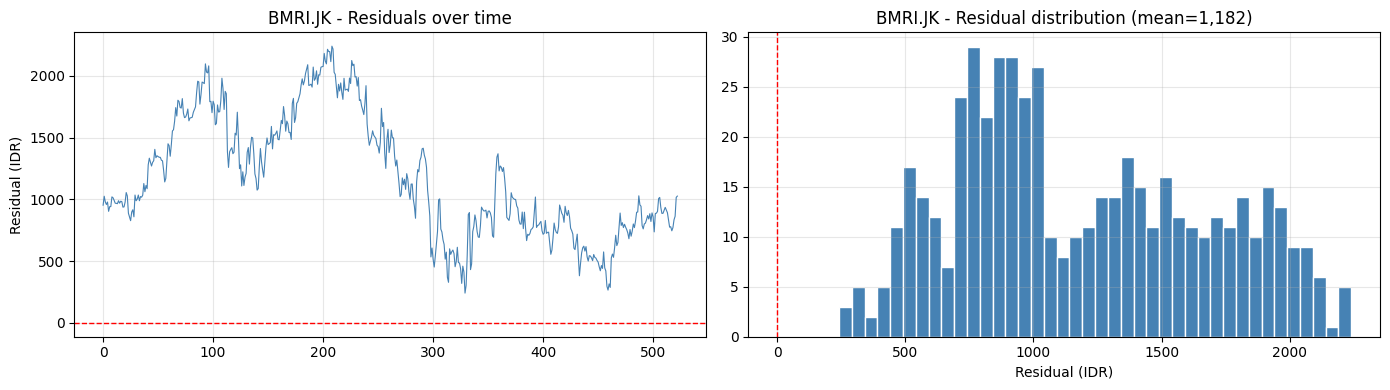

In [10]:
residuals = y_test_true - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals, color='steelblue', lw=0.8)
axes[0].axhline(0, color='red', linestyle='--', lw=1)
axes[0].set_title(f'{TICKER} - Residuals over time')
axes[0].set_ylabel('Residual (IDR)')
axes[0].grid(alpha=0.3)

mean_res = residuals.mean()
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1)
axes[1].set_title(f'{TICKER} - Residual distribution (mean={mean_res:,.0f})')
axes[1].set_xlabel('Residual (IDR)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, f'{SAFE_TICKER}_residuals.png'), dpi=120, bbox_inches='tight')
plt.show()

## Directional Accuracy

In [11]:
actual_dir     = np.sign(np.diff(y_test_true))
pred_dir       = np.sign(np.diff(y_test_pred))
model_da       = (actual_dir == pred_dir).mean() * 100
persist_da     = (actual_dir == np.zeros(len(actual_dir))).mean() * 100
mean_train_ret = np.diff(y_train_true).mean()
mean_ret_da    = (actual_dir == np.sign(np.full(len(actual_dir), mean_train_ret))).mean() * 100

da_df = pd.DataFrame({
    'Baseline': ['Model', 'Persistence (no-change)', 'Mean-Return'],
    'DA (%)':   [round(model_da, 2), round(persist_da, 2), round(mean_ret_da, 2)],
}).set_index('Baseline')
da_df['Beats Persistence'] = da_df['DA (%)'] > persist_da

display(da_df.style
    .background_gradient(subset=['DA (%)'], cmap='RdYlGn', vmin=40, vmax=65)
    .format({'DA (%)': '{:.2f}%'}))

,DA (%),Beats Persistence
Baseline,,
Model,44.64%,True
Persistence (no-change),11.11%,False
Mean-Return,43.68%,True


## Ljung-Box Test (Residual Whiteness)

In [12]:
lb = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
lb.index = [f'lag {i}' for i in lb.index]
lb['White noise (p>0.10)'] = lb['lb_pvalue'] > 0.10

display(lb.style.format({'lb_stat': '{:.4f}', 'lb_pvalue': '{:.4f}'}))

,lb_stat,lb_pvalue,White noise (p>0.10)
lag 5,2368.7488,0.0000,False
lag 10,4473.0905,0.0000,False
lag 20,8277.0173,0.0000,False


## KS-Test (Feature Distribution Shift)

In [13]:
train_flat = X_train.reshape(-1, n_features)
test_flat  = X_test.reshape(-1,  n_features)

ks_rows = []
for i, col in enumerate(feature_cols):
    stat, pval = ks_2samp(train_flat[:, i], test_flat[:, i])
    ks_rows.append({'Feature': col, 'KS stat': stat, 'p-value': pval, 'Shift': pval < 0.01})

ks_df = pd.DataFrame(ks_rows).set_index('Feature')
n_shift = ks_df['Shift'].sum()
print(f'Features with significant distribution shift (p<0.01): {n_shift} / {len(ks_df)}')

display(ks_df.style.format({'KS stat': '{:.3f}', 'p-value': '{:.4f}'}))

Features with significant distribution shift (p<0.01): 17 / 20


,KS stat,p-value,Shift
Feature,,,
Open,0.914,0.0000,True
High,0.924,0.0000,True
Low,0.913,0.0000,True
Close,0.919,0.0000,True
Volume,0.212,0.0000,True
ROE,0.000,1.0000,False
EPS,0.000,1.0000,False
DY,0.000,1.0000,False
MA7,0.925,0.0000,True


## Feature Importance (Permutation)

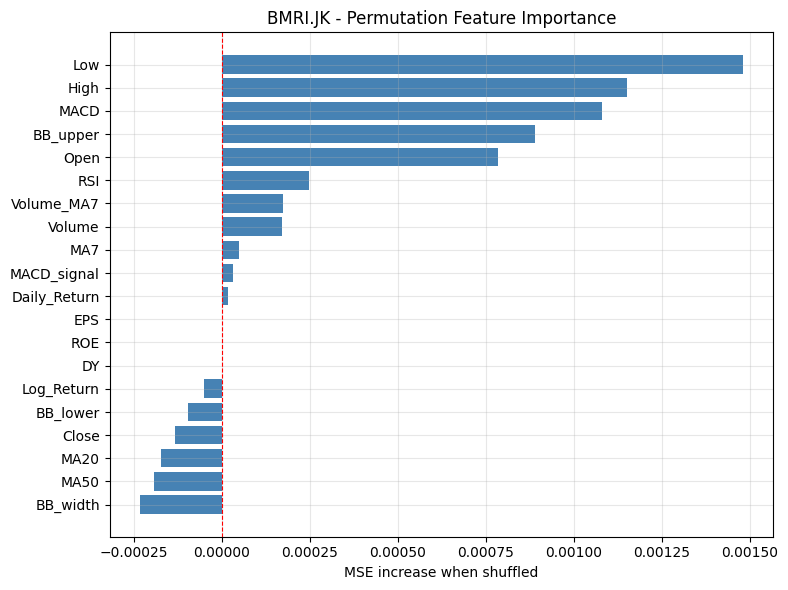

,Feature,Importance
2,Low,0.001481
1,High,0.001151
18,MACD,0.001080
12,BB_upper,0.000890
0,Open,0.000785
11,RSI,0.000249
17,Volume_MA7,0.000172
4,Volume,0.000171
8,MA7,0.000047
19,MACD_signal,0.000031


In [14]:
base_pred = ensemble[0].predict(X_test, verbose=0).flatten()
base_mse  = mean_squared_error(y_test, base_pred)

rng      = np.random.RandomState(42)
imp_rows = []
for i, col in enumerate(feature_cols):
    X_perm = X_test.copy()
    flat   = X_perm[:, :, i].flatten()
    rng.shuffle(flat)
    X_perm[:, :, i] = flat.reshape(X_test.shape[0], X_test.shape[1])
    perm_pred = ensemble[0].predict(X_perm, verbose=0).flatten()
    imp_rows.append({'Feature': col, 'Importance': mean_squared_error(y_test, perm_pred) - base_mse})

imp_df    = pd.DataFrame(imp_rows).sort_values('Importance', ascending=False)
sorted_df = imp_df.sort_values('Importance')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sorted_df['Feature'], sorted_df['Importance'], color='steelblue')
ax.axvline(0, color='red', lw=0.8, linestyle='--')
ax.set_title(f'{TICKER} - Permutation Feature Importance')
ax.set_xlabel('MSE increase when shuffled')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, f'{SAFE_TICKER}_feature_importance.png'), dpi=120, bbox_inches='tight')
plt.show()

display(imp_df.style.format({'Importance': '{:.6f}'}))

## 30-Day Forecast

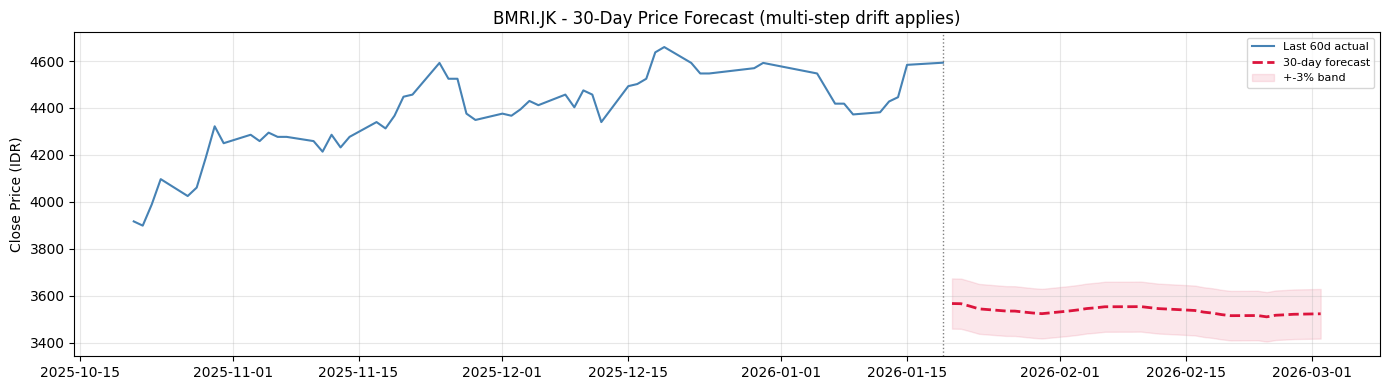

In [15]:
FORECAST_DAYS = 30

last_window     = X_test[-1].copy()
forecast_scaled = []

for _ in range(FORECAST_DAYS):
    pred = np.mean([m.predict(last_window[np.newaxis], verbose=0)[0, 0] for m in ensemble])
    forecast_scaled.append(pred)
    new_step              = last_window[-1].copy()
    new_step[target_idx]  = pred
    last_window           = np.vstack([last_window[1:], new_step])

forecast     = inverse_close(np.array(forecast_scaled))
last_actuals = y_test_true[-60:]
last_dates   = featured_data[TICKER].index[-60:]
future_dates = pd.bdate_range(start=last_dates[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last_dates,   last_actuals, color='steelblue', lw=1.5, label='Last 60d actual')
ax.plot(future_dates, forecast,     color='crimson',   lw=2, linestyle='--', label=f'{FORECAST_DAYS}-day forecast')
ax.fill_between(future_dates, forecast * 0.97, forecast * 1.03,
                color='crimson', alpha=0.1, label='+-3% band')
ax.axvline(last_dates[-1], color='gray', linestyle=':', lw=1)
ax.set_title(f'{TICKER} - {FORECAST_DAYS}-Day Price Forecast (multi-step drift applies)')
ax.set_ylabel('Close Price (IDR)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, f'{SAFE_TICKER}_forecast_30d.png'), dpi=120, bbox_inches='tight')
plt.show()

## Summary

In [16]:
test_m = compute_metrics(y_test_true, y_test_pred)

with mlflow.start_run(run_name=TICKER):
    mlflow.log_params({
        'ticker'        : TICKER,
        'ensemble_size' : len(SEEDS),
        'architecture'  : 'BiLSTM',
        'scaler'        : data.get('scaler_type', '?'),
        'target'        : 'raw_close',
        'window_size'   : window_size,
        'n_features'    : n_features,
        'loss'          : 'huber',
        **CONFIG,
    })
    mlflow.log_metrics({
        'test_mae' : test_m['MAE'],
        'test_rmse': test_m['RMSE'],
        'test_mape': test_m['MAPE'],
        'test_r2'  : test_m['R2'],
        'test_da'  : model_da,
    })

print(f'Ticker : {TICKER}')
print(f'R2     : {test_m["R2"]:.4f}')
print(f'RMSE   : {test_m["RMSE"]:,.2f}')
print(f'MAPE   : {test_m["MAPE"]:.4f}%')
print(f'DA     : {model_da:.2f}%')
print(f'\nMLflow : mlflow ui --backend-store-uri sqlite:///{MLFLOW_DB}')

Ticker : BMRI.JK
R2     : -3.3408
RMSE   : 1,277.97
MAPE   : 23.6904%
DA     : 44.64%

MLflow : mlflow ui --backend-store-uri sqlite:///c:\Users\akbar\VSCode Project\RaksaDana\mlflow.db
